# DX799 Week 5: Support Vector Machines

This notebook applies support vector machines, the kernel trick, and SVM regularization to the diabetes health indicators dataset from the BRFSS 2015 survey. Building on Weeks 1-4, we continue using the top predictive features (GenHlth, BMI, HighBP, Age, HighChol) identified through linear models, regularization, feature selection, and logistic regression.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## Load Data

We load the same BRFSS 2015 diabetes dataset used in Weeks 1-4.

In [2]:
df = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


## Feature Selection and Train/Test Split

Following the consistent top features identified across Weeks 1-4 (GenHlth, BMI, HighBP, Age, HighChol), we use these five features to train the SVM. Using a small, focused feature set also keeps training time manageable, since SVMs can be slow on large datasets with many features.

We split the data 80/20 into training and test sets, matching the approach from Week 4.

In [3]:
features = ['GenHlth', 'BMI', 'HighBP', 'Age', 'HighChol']
X = df[features]
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (56553, 5)
Test set: (14139, 5)


## Feature Scaling

SVMs are sensitive to the scale of input features because the algorithm relies on distances between points to find the maximum margin hyperplane. Features on different scales (BMI ranges roughly 12-98, while HighBP and HighChol are binary 0/1) would cause the SVM to weight large-scale features too heavily. We scale all features using StandardScaler, matching the scaling approach from Week 4's logistic regression.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data sample:")
print(X_train_scaled[:3])

Scaled training data sample:
[[ 1.04867612 -0.68737118  0.8807157   0.84937208 -1.05078118]
 [ 1.94810711 -0.40577633  0.8807157   0.84937208  0.95167293]
 [ 1.04867612 -0.40577633  0.8807157  -0.20216445 -1.05078118]]


## Linear Kernel SVM

We start with the simplest case: a linear kernel. This means the SVM looks for a straight-line hyperplane (in our 5-dimensional feature space) that separates patients predicted to have diabetes from those predicted not to.

Note: SVMs can be slow to train on large datasets. To keep training time reasonable, we train on a 5,000-row sample of the training set rather than the full 56,553 rows. This is a common practical approach when first exploring SVM behavior before committing to a full run.

In [5]:
# Use a sample for faster training
sample_size = 5000
X_train_sample = X_train_scaled[:sample_size]
y_train_sample = y_train[:sample_size]

svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_sample, y_train_sample)

y_pred_linear = svm_linear.predict(X_test_scaled)
acc_linear = accuracy_score(y_test, y_pred_linear)
auc_linear = roc_auc_score(y_test, svm_linear.decision_function(X_test_scaled))

print(f"Linear Kernel SVM")
print(f"Accuracy: {acc_linear:.4f}")
print(f"AUC-ROC: {auc_linear:.4f}")

Linear Kernel SVM
Accuracy: 0.7373
AUC-ROC: 0.8149


## Polynomial Kernel SVM

Next we try a polynomial kernel, which uses the kernel trick to let the SVM find a curved decision boundary instead of a straight line. The polynomial kernel computes K(x,z) = (x^T z + c)^d, allowing the SVM to consider combinations of features (like interactions) without explicitly creating those new feature columns ourselves. We use d

In [6]:
svm_poly = SVC(kernel='poly', degree=3, random_state=42)
svm_poly.fit(X_train_sample, y_train_sample)

y_pred_poly = svm_poly.predict(X_test_scaled)
acc_poly = accuracy_score(y_test, y_pred_poly)
auc_poly = roc_auc_score(y_test, svm_poly.decision_function(X_test_scaled))

print(f"Polynomial Kernel SVM (degree 3)")
print(f"Accuracy: {acc_poly:.4f}")
print(f"AUC-ROC: {auc_poly:.4f}")

Polynomial Kernel SVM (degree 3)
Accuracy: 0.7293
AUC-ROC: 0.7994


## Gaussian (RBF) Kernel SVM

The Gaussian, or RBF (Radial Basis Function), kernel is the most flexible of the three. It can create highly curved, complex decision boundaries by measuring similarity based on the distance between points, without ever computing the points in the higher-dimensional space directly. This is the clearest example of the kernel trick: the Gaussian kernel does not correspond to any specific finite-dimensional inner product, yet the SVM still works because it only needs the kernel values, not the underlying coordinates.

In [7]:
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_sample, y_train_sample)

y_pred_rbf = svm_rbf.predict(X_test_scaled)
acc_rbf = accuracy_score(y_test, y_pred_rbf)
auc_rbf = roc_auc_score(y_test, svm_rbf.decision_function(X_test_scaled))

print(f"RBF Kernel SVM")
print(f"Accuracy: {acc_rbf:.4f}")
print(f"AUC-ROC: {auc_rbf:.4f}")

RBF Kernel SVM
Accuracy: 0.7404
AUC-ROC: 0.8011


## Regularization Parameter C

The C parameter controls the tradeoff between a wide margin and correctly classifying training points. A small C allows a wider margin but tolerates more misclassified points. A large C tries harder to classify every point correctly, even if it means a narrower margin. We test a few values of C using the linear kernel, since it performed best so far, to see how this tradeoff affects performance on our data.

In [8]:
C_values = [0.01, 0.1, 1, 10]
results = []

for C in C_values:
    svm_c = SVC(kernel='linear', C=C, random_state=42)
    svm_c.fit(X_train_sample, y_train_sample)
    y_pred_c = svm_c.predict(X_test_scaled)
    acc_c = accuracy_score(y_test, y_pred_c)
    auc_c = roc_auc_score(y_test, svm_c.decision_function(X_test_scaled))
    results.append({'C': C, 'Accuracy': acc_c, 'AUC-ROC': auc_c})

results_df = pd.DataFrame(results)
print(results_df)

       C  Accuracy   AUC-ROC
0   0.01  0.736756  0.814186
1   0.10  0.737676  0.814579
2   1.00  0.737322  0.814856
3  10.00  0.737322  0.814859


## Visualizing the Decision Boundary

To visualize how an SVM separates classes, we train a simplified linear kernel SVM using only two features, GenHlth and BMI, the two strongest predictors from prior weeks. This lets us plot the decision boundary, the margin, and the support vectors directly.

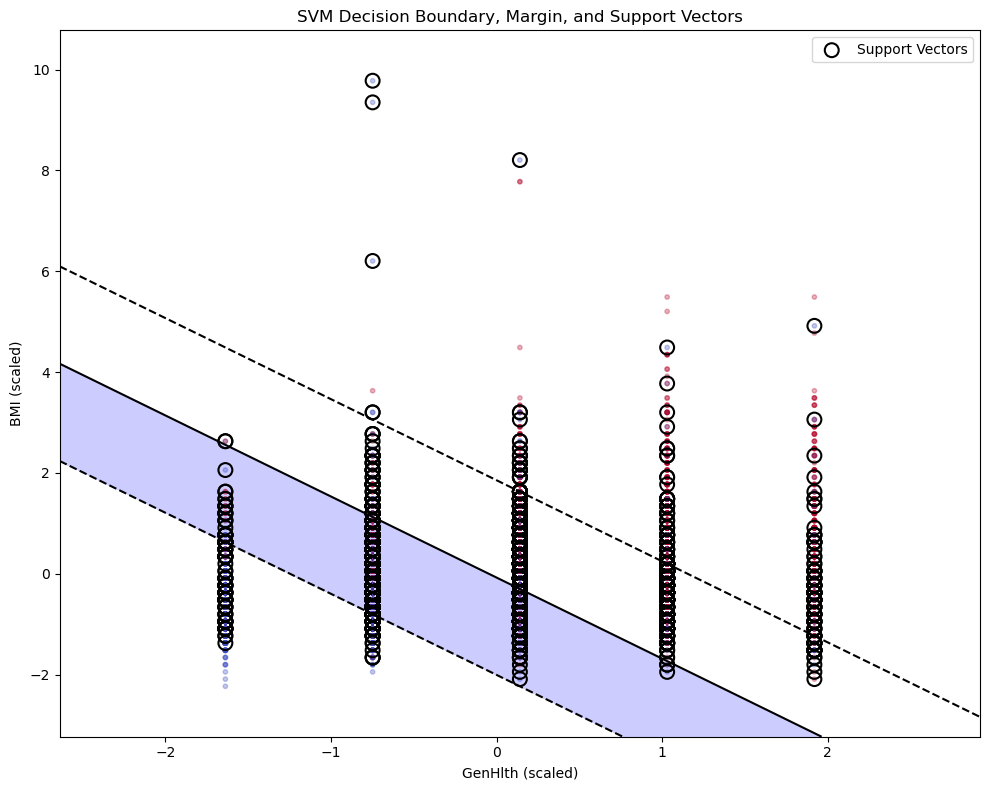

In [11]:
features_2d = ['GenHlth', 'BMI']
sample_df = df.sample(n=5000, random_state=42)
X_2d = sample_df[features_2d].values
y_2d = sample_df['Diabetes_binary'].values

scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

svm_2d = SVC(kernel='linear', C=1, random_state=42)
svm_2d.fit(X_2d_scaled, y_2d)

# Create a mesh grid for plotting
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.2, colors=['blue', 'white', 'red'])
plt.contour(xx, yy, Z, colors='black', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
plt.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y_2d, cmap='coolwarm', alpha=0.3, s=10)
plt.scatter(svm_2d.support_vectors_[:, 0], svm_2d.support_vectors_[:, 1],
            facecolors='none', edgecolors='black', s=100, linewidths=1.5, label='Support Vectors')
plt.xlabel('GenHlth (scaled)')
plt.ylabel('BMI (scaled)')
plt.title('SVM Decision Boundary, Margin, and Support Vectors')
plt.legend()
plt.tight_layout()
plt.savefig('week5_svm_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Kernel | Accuracy | AUC-ROC |
|---|---|---|
| Linear | 0.7373 | 0.8149 |
| Polynomial (degree 3) | 0.7293 | 0.7994 |
| RBF | 0.7404 | 0.8011 |

The linear kernel achieved the best AUC-ROC, while RBF achieved the best raw accuracy, but the differences across kernels are small. Varying the regularization parameter C from 0.01 to 10 had almost no effect on performance (accuracy 0.7368-0.7376, AUC-ROC 0.8142-0.8149), suggesting the dataset does not have a small number of difficult-to-classify outliers driving a margin/misclassification tradeoff.

These results are consistent with prior weeks: the relationship between health indicators and diabetes risk in this dataset is largely linear, and increasing model complexity (polynomial or RBF kernels) does not meaningfully improve performance over a linear approach. SVM performance (linear, 0.8149 AUC-ROC) falls slightly short of Week 4's logistic regression (0.8232 AUC-ROC), reinforcing logistic regression as the strongest model so far.

The visualization using GenHlth and BMI shows a large number of support vectors, likely because both features are ordinal with limited unique values, causing many points to fall on or near the margin.